# CSV to Clean Text to Engineered Features

This notebook is designed to tell the feature-engineering story from the original CSV data and connect it to the saved tuning results.

Goals:
- Inspect comments before cleaning and after cleaning
- Show how cleaning changes the text distribution
- Connect cleaned text to the engineered features in `toxic_pipeline.py`
- Visualize which engineered features provide useful toxicity signals
- Compare the saved tuning artifact families on the shared word-only pipeline


In [97]:
import re
from collections import Counter
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split

from toxic_pipeline import (
    ALL_ENGINEERED_FEATURE_COLUMNS,
    FEATURE_COLUMNS,
    _reduce_scaler_to_features,
    build_all_engineered_features,
    clean_text,
    protect_non_toxic_negations,
    resolve_data_path,
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.options.display.max_columns = 50
pd.options.display.max_colwidth = 140

PALETTE = {
    "Not Toxic": "#4c78a8",
    "Toxic": "#e45756",
}


In [98]:
def tokenize_raw(text: str) -> list[str]:
    return re.findall(r"[A-Za-z']+", str(text).lower())


def top_tokens(series: pd.Series, tokenizer, top_n: int = 15) -> pd.DataFrame:
    counter = Counter()
    for text in series:
        counter.update(tokenizer(text))
    most_common = counter.most_common(top_n)
    return pd.DataFrame(most_common, columns=["token", "count"])


In [99]:
data_path = resolve_data_path()
raw_df = pd.read_csv(data_path, usecols=["comment_text", "toxic"]).rename(
    columns={"comment_text": "raw_text"}
)

raw_df["protected_text"] = raw_df["raw_text"].apply(protect_non_toxic_negations)
raw_df["clean_text"] = raw_df["protected_text"].apply(clean_text)
raw_df["label"] = raw_df["toxic"].map({0: "Not Toxic", 1: "Toxic"})
raw_df["raw_character_count"] = raw_df["raw_text"].astype(str).str.len()
raw_df["clean_character_count"] = raw_df["clean_text"].astype(str).str.len()
raw_df["raw_word_count"] = raw_df["raw_text"].apply(lambda text: len(tokenize_raw(text)))
raw_df["clean_word_count"] = raw_df["clean_text"].apply(lambda text: len(str(text).split()))
raw_df["characters_removed"] = (
    raw_df["raw_character_count"] - raw_df["clean_character_count"]
)
raw_df["words_removed"] = raw_df["raw_word_count"] - raw_df["clean_word_count"]
raw_df["changed_by_cleaning"] = raw_df["raw_text"] != raw_df["clean_text"]

feature_df = pd.concat(
    [build_all_engineered_features(text) for text in raw_df["raw_text"]],
    ignore_index=True,
)

analysis_df = pd.concat([raw_df.reset_index(drop=True), feature_df], axis=1)

print(f"Loaded {len(analysis_df):,} comments from: {data_path}")
print(f"All engineered features ({len(ALL_ENGINEERED_FEATURE_COLUMNS)}):")
print(ALL_ENGINEERED_FEATURE_COLUMNS)
print()
print(f"Current runtime-selected features ({len(FEATURE_COLUMNS)}):")
print(FEATURE_COLUMNS)
print()
print("The saved-model comparison below will show which artifact family has the best held-out F1.")


Loaded 159,571 comments from: D:\Code\Repos\CPE232\project\data\train.csv
All engineered features (16):
['Character Count', 'Word Count', 'Exclamation Count', 'Profanity Count', 'Strong Toxic Signal Flag', 'Second-person Pronoun Count', 'Repeated Character Pattern Count', 'Average Word Length', 'Uppercase Ratio', 'Question Mark Count', 'Repeated Punctuation Count', 'Identity-group Term Count', 'URL Count', 'Negation Count', 'Non-toxic Negation Pattern Count', 'Short/Unclear Without Toxic Signal Flag']

Current runtime-selected features (7):
['Question Mark Count', 'Profanity Count', 'Repeated Punctuation Count', 'Short/Unclear Without Toxic Signal Flag', 'Second-person Pronoun Count', 'URL Count', 'Non-toxic Negation Pattern Count']

The saved-model comparison below will show which artifact family has the best held-out F1.


## Before and After Cleaning

This section stays close to the CSV itself and shows how the raw comments are normalized before feature extraction.


In [100]:
changed_examples = (
    analysis_df.loc[analysis_df["changed_by_cleaning"], ["label", "raw_text", "clean_text"]]
    .sample(8, random_state=42)
    .reset_index(drop=True)
)
display(changed_examples)


,label,raw_text,clean_text
0,Not Toxic,"""\n\nMy point exactly!! \n\nberlet is adding extensive unsourced original research\n\nCberlet is adding extensive orginal research and ...",my point exactly berlet is adding extensive unsourced original research cberlet is adding extensive orginal research and wildly pov asse...
1,Not Toxic,"Once again, you don't know what you are talking about! There are only two primary sources for Ambrosius, and they are Gildas (the main s...",once again you do not know what you are talking about there are only two primary sources for ambrosius and they are gildas the main sour...
2,Not Toxic,Some advice \n\nAn article on MacroData Netdrive has already been deleted once. Please see Wikipedia:Articles for deletion/MacroData Net...,some advice an article on macrodata netdrive has already been deleted once please see wikipedia articles for deletion macrodata netdrive...
3,Toxic,What the F son? \n\nHere I am trying to educate the internet at large and you come along acting like there's sand trapped in your vagina...,what the f son here i am trying to educate the internet at large and you come along acting like there is sand trapped in your vagina you...
4,Not Toxic,"Information about Trivandrum Int'l Airport\n\n1. Best Airport - Aarem, can this weasel and unreal statement please be removed? This does...",information about trivandrum int l airport best airport aarem can this weasel and unreal statement please be removed this does not seem ...
5,Not Toxic,"""\n\n Happy New Year 2006 \nA year has only 365 days, and if you live to 100 years U get 36,500 and so if you saved a dollar a day, it i...",happy new year a year has only days and if you live to years you get and so if you saved a dollar a day it is only no very much is there...
6,Not Toxic,"""It's officially """"Yeager"""" in Kodansha's translation. Not """"Jaeger"""".— (琉竜) """,it is officially yeager in kodansha s translation not jaeger
7,Not Toxic,"Question \n\nRussavia, just before you were blocked you were running around,accusing ArbCom in harassment and the lack of transparency....",question russavia just before you were blocked you were running around accusing arbcom in harassment and the lack of transparency you vo...


In [101]:
cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "Total comments",
            "Toxic comments",
            "Comments changed by cleaning",
            "Average raw character count",
            "Average clean character count",
            "Average raw word count",
            "Average clean word count",
            "Average characters removed",
            "Average words removed",
        ],
        "value": [
            len(analysis_df),
            int(analysis_df["toxic"].sum()),
            analysis_df["changed_by_cleaning"].mean(),
            analysis_df["raw_character_count"].mean(),
            analysis_df["clean_character_count"].mean(),
            analysis_df["raw_word_count"].mean(),
            analysis_df["clean_word_count"].mean(),
            analysis_df["characters_removed"].mean(),
            analysis_df["words_removed"].mean(),
        ],
    }
)

by_class_summary = (
    analysis_df.groupby("label")[[
        "raw_character_count",
        "clean_character_count",
        "raw_word_count",
        "clean_word_count",
        "characters_removed",
        "words_removed",
        "changed_by_cleaning",
    ]]
    .mean()
    .round(2)
)

display(cleaning_summary)
display(by_class_summary)


,metric,value
0,Total comments,159571.000000
1,Toxic comments,15294.000000
2,Comments changed by cleaning,0.992724
3,Average raw character count,394.073221
4,Average clean character count,370.925413
5,Average raw word count,67.045992
6,Average clean word count,67.689887
7,Average characters removed,23.147809
8,Average words removed,-0.643895


,raw_character_count,clean_character_count,raw_word_count,clean_word_count,characters_removed,words_removed,changed_by_cleaning
label,,,,,,,
Not Toxic,404.55,380.87,68.67,69.30,23.68,-0.62,0.99
Toxic,295.25,277.13,51.68,52.53,18.12,-0.84,0.98


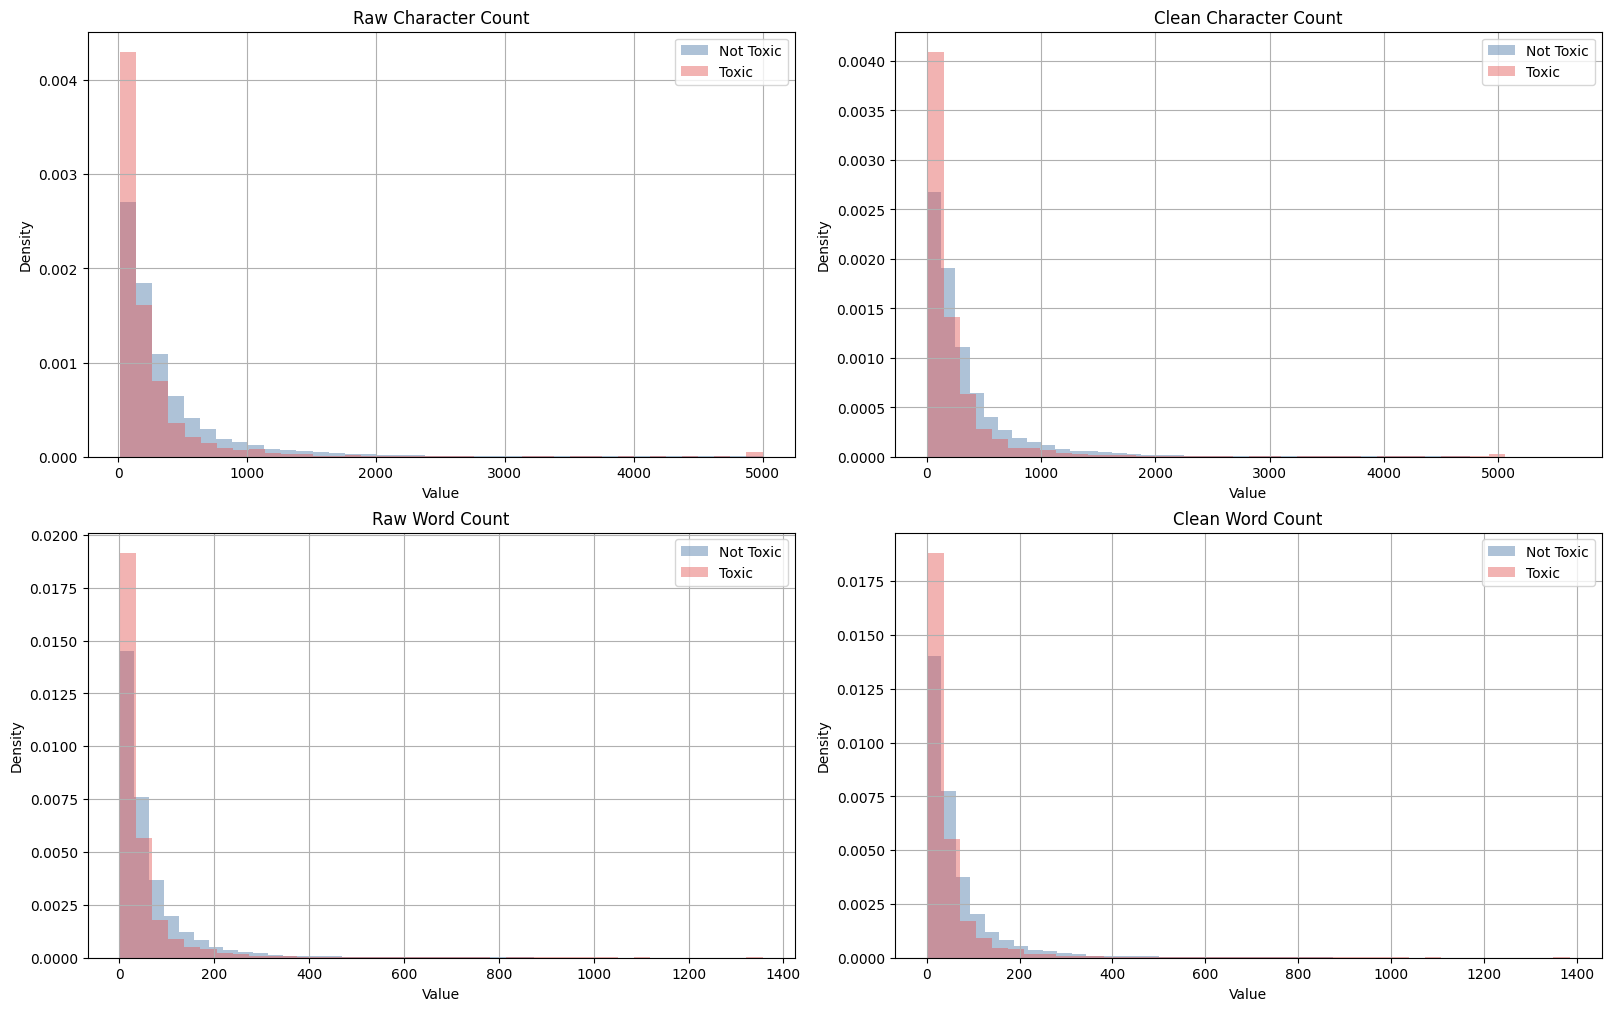

In [102]:
plot_sample = analysis_df.sample(n=min(50000, len(analysis_df)), random_state=42).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for label in ["Not Toxic", "Toxic"]:
    subset = plot_sample.loc[plot_sample["label"] == label]
    axes[0, 0].hist(
        subset["raw_character_count"],
        bins=40,
        alpha=0.45,
        density=True,
        color=PALETTE[label],
        label=label,
    )
    axes[0, 1].hist(
        subset["clean_character_count"],
        bins=40,
        alpha=0.45,
        density=True,
        color=PALETTE[label],
        label=label,
    )
    axes[1, 0].hist(
        subset["raw_word_count"],
        bins=40,
        alpha=0.45,
        density=True,
        color=PALETTE[label],
        label=label,
    )
    axes[1, 1].hist(
        subset["clean_word_count"],
        bins=40,
        alpha=0.45,
        density=True,
        color=PALETTE[label],
        label=label,
    )

axes[0, 0].set_title("Raw Character Count")
axes[0, 1].set_title("Clean Character Count")
axes[1, 0].set_title("Raw Word Count")
axes[1, 1].set_title("Clean Word Count")

for ax in axes.ravel():
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.show()


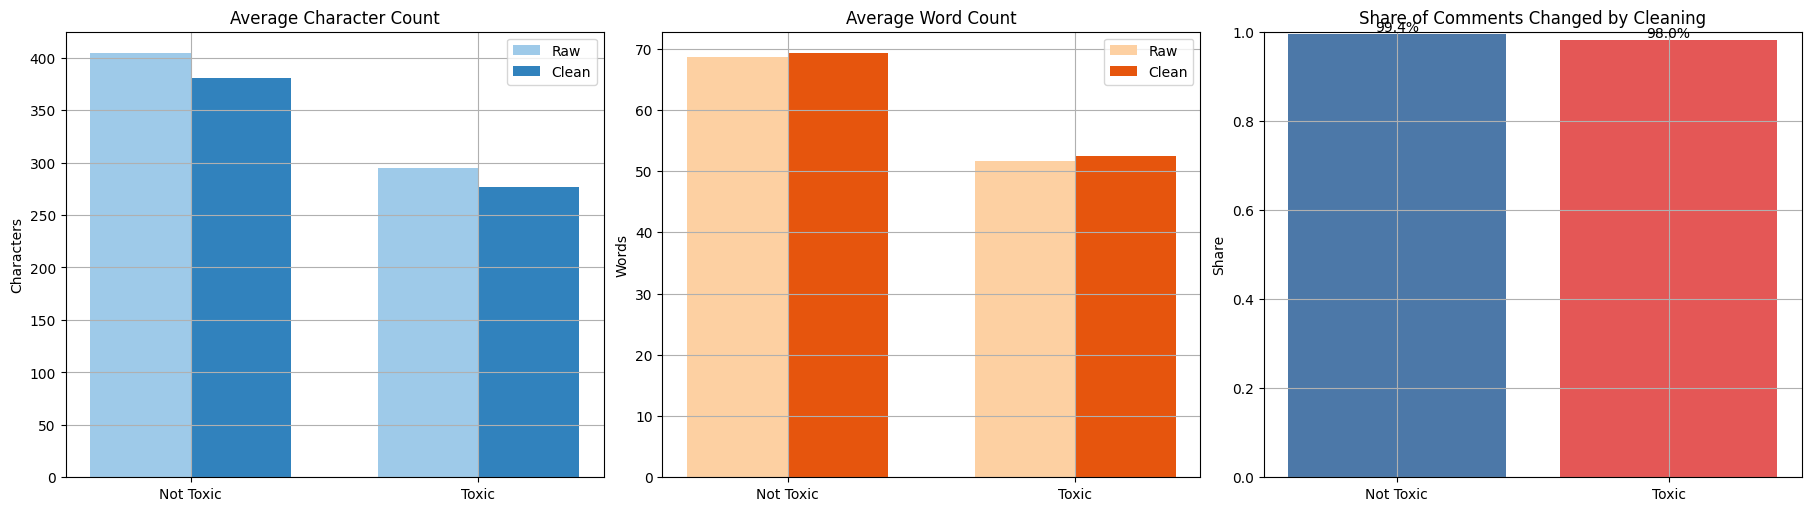

In [103]:
class_order = ["Not Toxic", "Toxic"]
x = np.arange(len(class_order))
bar_width = 0.35

raw_chars = [analysis_df.loc[analysis_df["label"] == label, "raw_character_count"].mean() for label in class_order]
clean_chars = [analysis_df.loc[analysis_df["label"] == label, "clean_character_count"].mean() for label in class_order]
raw_words = [analysis_df.loc[analysis_df["label"] == label, "raw_word_count"].mean() for label in class_order]
clean_words = [analysis_df.loc[analysis_df["label"] == label, "clean_word_count"].mean() for label in class_order]
changed_pct = [analysis_df.loc[analysis_df["label"] == label, "changed_by_cleaning"].mean() for label in class_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].bar(x - bar_width / 2, raw_chars, bar_width, color="#9ecae9", label="Raw")
axes[0].bar(x + bar_width / 2, clean_chars, bar_width, color="#3182bd", label="Clean")
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_order)
axes[0].set_title("Average Character Count")
axes[0].set_ylabel("Characters")
axes[0].legend()

axes[1].bar(x - bar_width / 2, raw_words, bar_width, color="#fdd0a2", label="Raw")
axes[1].bar(x + bar_width / 2, clean_words, bar_width, color="#e6550d", label="Clean")
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_order)
axes[1].set_title("Average Word Count")
axes[1].set_ylabel("Words")
axes[1].legend()

axes[2].bar(class_order, changed_pct, color=[PALETTE[label] for label in class_order])
axes[2].set_title("Share of Comments Changed by Cleaning")
axes[2].set_ylabel("Share")
axes[2].set_ylim(0, 1)

for idx, value in enumerate(changed_pct):
    axes[2].text(idx, value, f"{value:.1%}", ha="center", va="bottom")

plt.show()


## Token-Level Insight Before and After Cleaning

These plots help show how cleaning removes formatting noise and makes lexical patterns easier to measure.


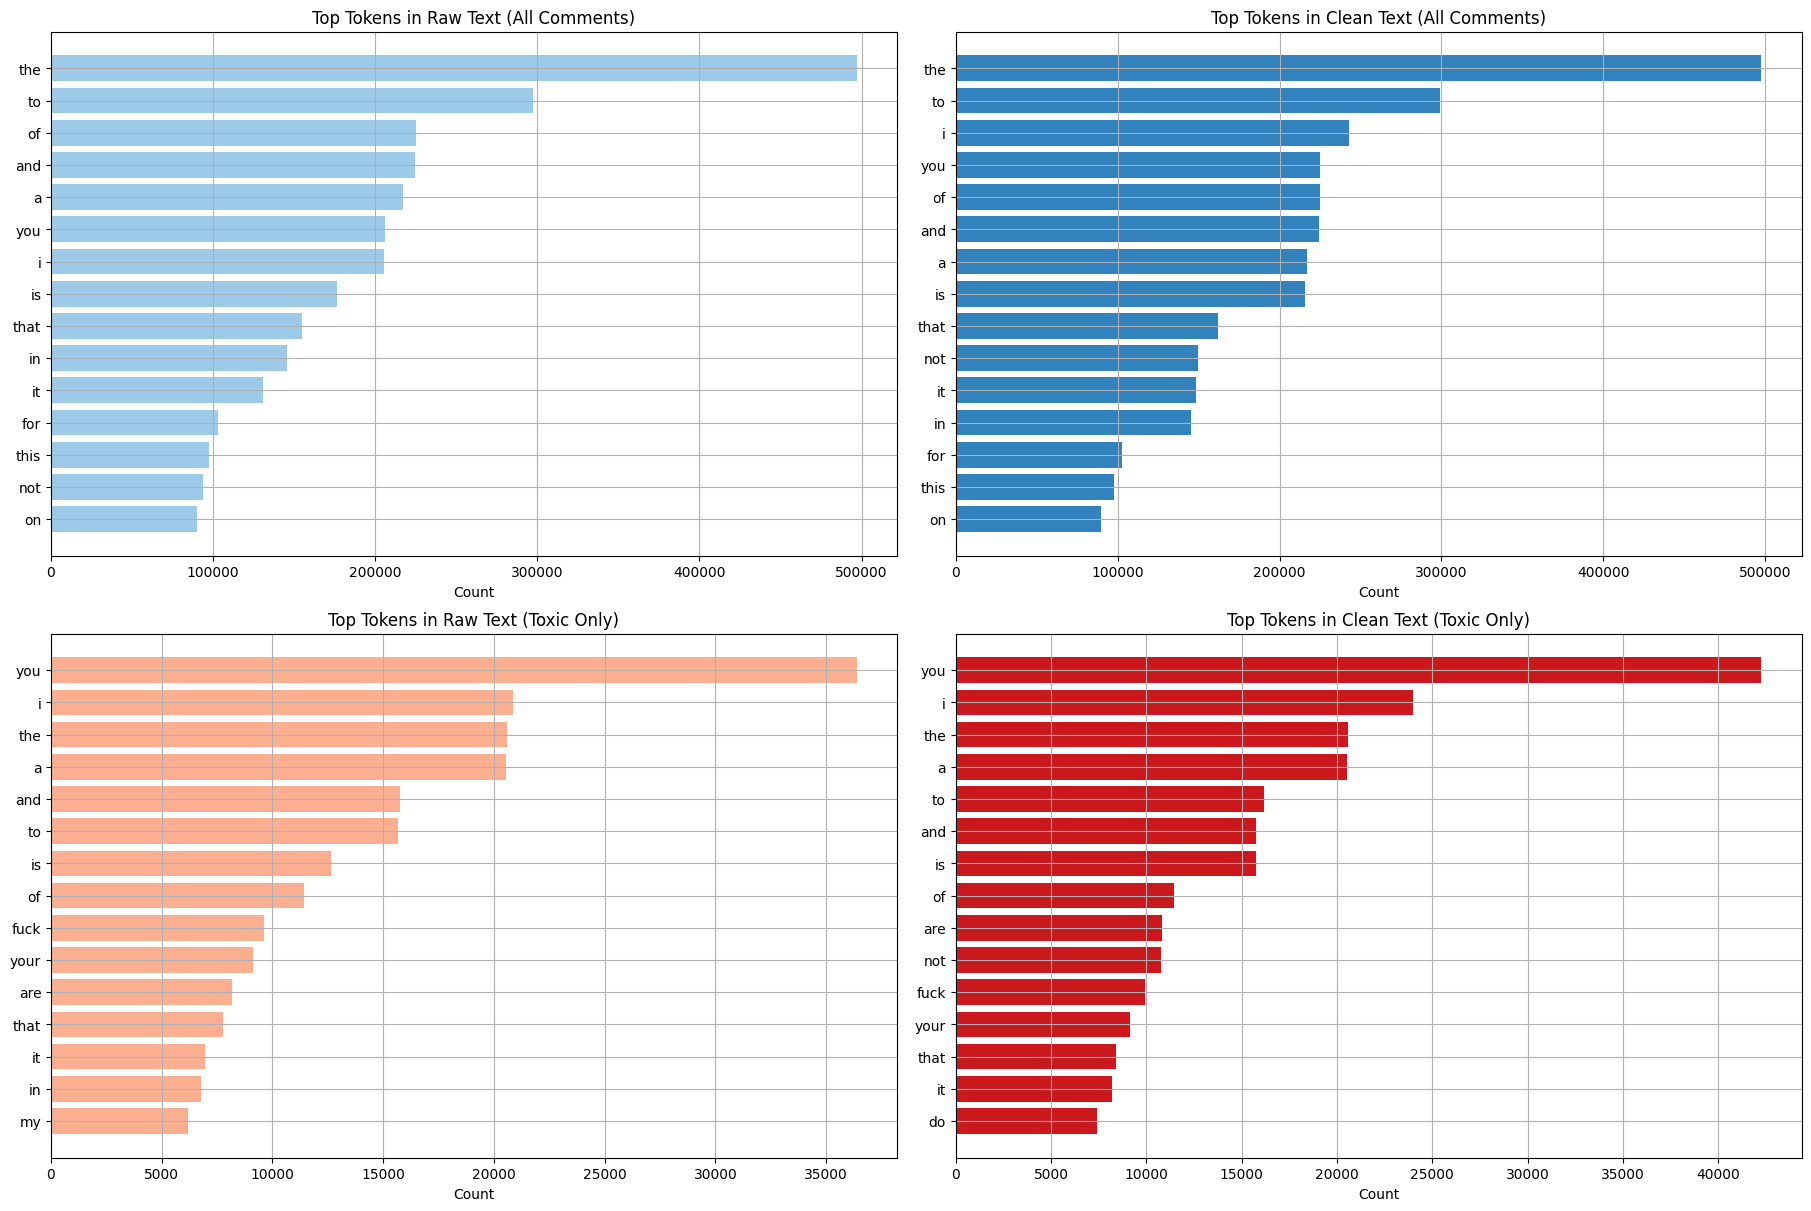

In [104]:
overall_raw_tokens = top_tokens(analysis_df["raw_text"], tokenize_raw, top_n=15)
overall_clean_tokens = top_tokens(analysis_df["clean_text"], lambda text: str(text).split(), top_n=15)
toxic_raw_tokens = top_tokens(
    analysis_df.loc[analysis_df["label"] == "Toxic", "raw_text"],
    tokenize_raw,
    top_n=15,
)
toxic_clean_tokens = top_tokens(
    analysis_df.loc[analysis_df["label"] == "Toxic", "clean_text"],
    lambda text: str(text).split(),
    top_n=15,
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

token_views = [
    (overall_raw_tokens, axes[0, 0], "Top Tokens in Raw Text (All Comments)", "#9ecae9"),
    (overall_clean_tokens, axes[0, 1], "Top Tokens in Clean Text (All Comments)", "#3182bd"),
    (toxic_raw_tokens, axes[1, 0], "Top Tokens in Raw Text (Toxic Only)", "#fcae91"),
    (toxic_clean_tokens, axes[1, 1], "Top Tokens in Clean Text (Toxic Only)", "#cb181d"),
]

for token_df, ax, title, color in token_views:
    ax.barh(token_df["token"], token_df["count"], color=color)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.show()


## How Cleaned Text Becomes Features

This table bridges the transformation from raw text to engineered signals. Each example is chosen because it activates at least one useful feature pattern.


In [105]:
feature_example_specs = [
    ("Question mark", analysis_df["Question Mark Count"] > 0),
    ("Profanity", analysis_df["Profanity Count"] > 0),
    ("Repeated punctuation", analysis_df["Repeated Punctuation Count"] > 0),
    ("Short unclear", analysis_df["Short/Unclear Without Toxic Signal Flag"] > 0),
    ("Second-person pronoun", analysis_df["Second-person Pronoun Count"] > 0),
    ("URL", analysis_df["URL Count"] > 0),
    ("Protected non-toxic negation", analysis_df["Non-toxic Negation Pattern Count"] > 0),
]

example_rows = []
for scenario, mask in feature_example_specs:
    subset = analysis_df.loc[mask]
    if subset.empty:
        continue
    row = subset.iloc[0]
    example_rows.append(
        {
            "scenario": scenario,
            "label": row["label"],
            "raw_text": row["raw_text"],
            "clean_text": row["clean_text"],
            "Question Mark Count": row["Question Mark Count"],
            "Profanity Count": row["Profanity Count"],
            "Repeated Punctuation Count": row["Repeated Punctuation Count"],
            "Second-person Pronoun Count": row["Second-person Pronoun Count"],
            "URL Count": row["URL Count"],
            "Non-toxic Negation Pattern Count": row["Non-toxic Negation Pattern Count"],
            "Short/Unclear Without Toxic Signal Flag": row["Short/Unclear Without Toxic Signal Flag"],
        }
    )

feature_examples = pd.DataFrame(example_rows)
display(feature_examples)


,scenario,label,raw_text,clean_text,Question Mark Count,Profanity Count,Repeated Punctuation Count,Second-person Pronoun Count,URL Count,Non-toxic Negation Pattern Count,Short/Unclear Without Toxic Signal Flag
0,Question mark,Not Toxic,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GA...",explanation why the edits made under my username hardcore metallica fan were reverted they were not vandalisms just closure on some gas ...,1,0,0,0,0,0,0
1,Profanity,Toxic,"You are gay or antisemmitian? \n\nArchangel WHite Tiger\n\nMeow! Greetingshhh!\n\nUh, there are two ways, why you do erased my comment a...",you are gay or antisemmitian archangel white tiger meow greetingshhh uh there are two ways why you do erased my comment about ww that ho...,1,1,1,3,0,0,0
2,Repeated punctuation,Toxic,"Hey... what is it..\n@ | talk .\nWhat is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed puris...",hey what is it talk what is it an exclusive group of some wp talibans who are good at destroying self appointed purist who gang up any o...,1,0,5,0,0,0,0
3,Short unclear,Not Toxic,"86.29.244.57|86.29.244.57]] 04:21, 14 May 2007",may,0,0,0,0,0,0,1
4,Second-person pronoun,Not Toxic,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ...",more i cannot make any real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types ...,0,0,0,1,0,0,0
5,URL,Not Toxic,"""\n\n Snowflakes are NOT always symmetrical! \n\nUnder Geometry it is stated that """"A snowflake always has six symmetric arms."""" This as...",snowflakes are not always symmetrical under geometry it is stated that a snowflake always has six symmetric arms this assertion is simpl...,0,0,0,0,1,0,0
6,Protected non-toxic negation,Not Toxic,"And btw, speaking of the Armenian genocide, if we are to follow wikipedia conventions of most common name (and I don't agree Assyrian is...",and by the way speaking of the armenian genocide if we are to follow wikipedia conventions of most common name and i supportivephrase as...,0,0,0,0,0,1,0


## Feature Scorecard

This table summarizes the current runtime-selected engineered features with a few simple signals:
- `support_pct`: how often the feature is active (`> 0`)
- `active_toxic_rate`: toxic rate among comments where the feature is active
- `active_rate_uplift`: how much higher that toxic rate is than the dataset baseline
- `mean_ratio`: average feature value in toxic comments divided by the average value in non-toxic comments

These are not model coefficients, but they help show how the active 7-column runtime feature set separates the classes.


In [106]:
base_toxic_rate = analysis_df["toxic"].mean()
score_rows = []

for feature in FEATURE_COLUMNS:
    series = analysis_df[feature]
    active_mask = series > 0
    toxic_mean = analysis_df.loc[analysis_df["toxic"] == 1, feature].mean()
    non_toxic_mean = analysis_df.loc[analysis_df["toxic"] == 0, feature].mean()
    active_toxic_rate = analysis_df.loc[active_mask, "toxic"].mean() if active_mask.any() else np.nan
    inactive_toxic_rate = analysis_df.loc[~active_mask, "toxic"].mean() if (~active_mask).any() else np.nan

    score_rows.append(
        {
            "feature": feature,
            "support_pct": active_mask.mean(),
            "toxic_mean": toxic_mean,
            "non_toxic_mean": non_toxic_mean,
            "mean_ratio": toxic_mean / max(non_toxic_mean, 1e-9),
            "active_toxic_rate": active_toxic_rate,
            "inactive_toxic_rate": inactive_toxic_rate,
            "active_rate_uplift": active_toxic_rate / max(base_toxic_rate, 1e-9),
            "selected": True,
        }
    )

feature_scorecard = pd.DataFrame(score_rows).sort_values(
    ["active_rate_uplift", "mean_ratio"],
    ascending=[False, False],
).reset_index(drop=True)

display(feature_scorecard.round(3))


,feature,support_pct,toxic_mean,non_toxic_mean,mean_ratio,active_toxic_rate,inactive_toxic_rate,active_rate_uplift,selected
0,Profanity Count,0.060,1.977,0.019,101.780,0.764,0.053,7.975,True
1,Repeated Punctuation Count,0.113,0.570,0.178,3.199,0.158,0.088,1.653,True
2,Non-toxic Negation Pattern Count,0.010,0.015,0.010,1.514,0.139,0.095,1.454,True
3,Second-person Pronoun Count,0.229,0.734,0.411,1.787,0.123,0.088,1.286,True
4,Question Mark Count,0.254,0.585,0.435,1.346,0.094,0.097,0.976,True
5,URL Count,0.032,0.022,0.054,0.404,0.045,0.098,0.470,True
6,Short/Unclear Without Toxic Signal Flag,0.005,0.001,0.005,0.149,0.016,0.096,0.163,True


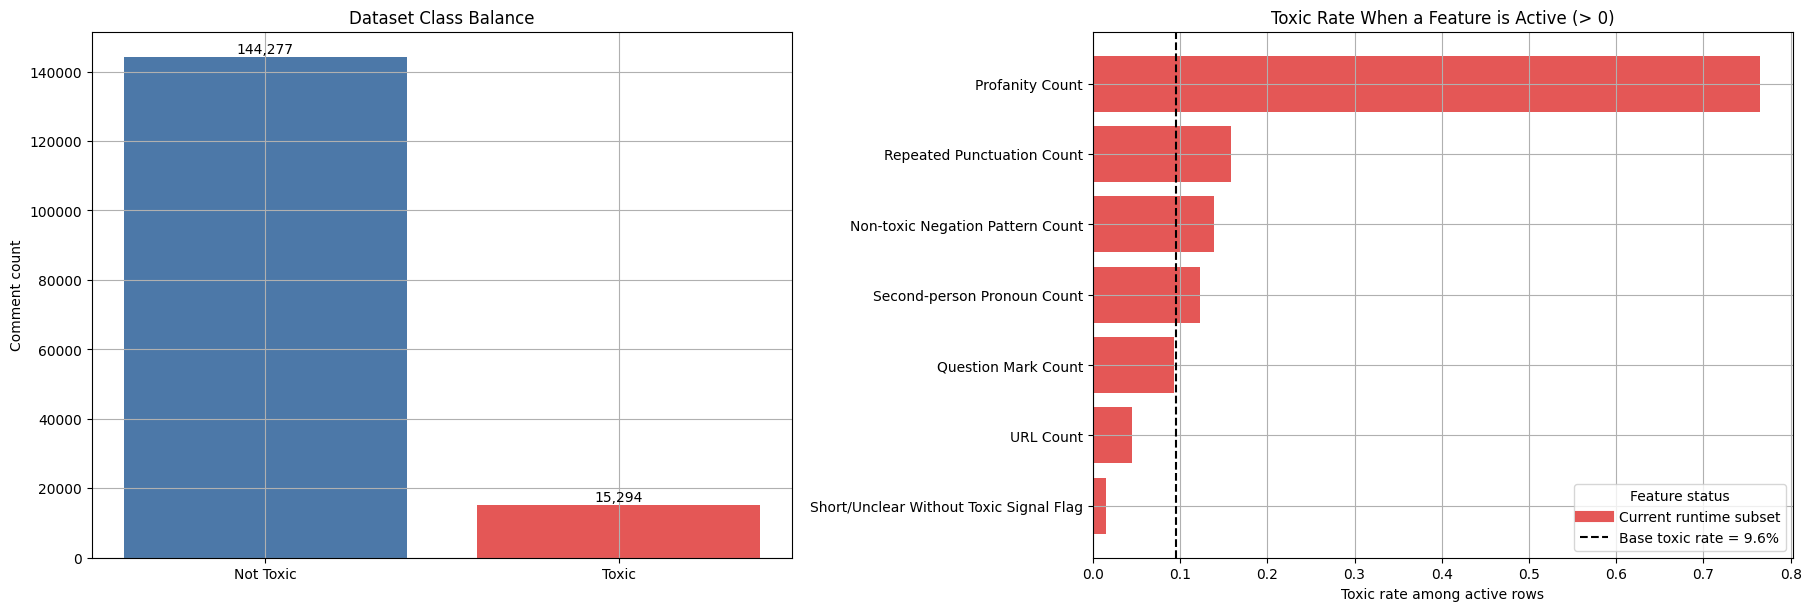

In [107]:
top_features = feature_scorecard.sort_values("active_rate_uplift", ascending=False).head(12).copy()
class_counts = analysis_df["label"].value_counts().reindex(["Not Toxic", "Toxic"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

axes[0].bar(class_counts.index, class_counts.values, color=[PALETTE[label] for label in class_counts.index])
axes[0].set_title("Dataset Class Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Comment count")
for idx, value in enumerate(class_counts.values):
    axes[0].text(idx, value, f"{value:,}", ha="center", va="bottom")

bar_colors = ["#e45756"] * len(top_features)
axes[1].barh(top_features["feature"], top_features["active_toxic_rate"], color=bar_colors)
axes[1].invert_yaxis()
axes[1].axvline(
    base_toxic_rate,
    color="black",
    linestyle="--",
    linewidth=1.5,
)
axes[1].set_title("Toxic Rate When a Feature is Active (> 0)")
axes[1].set_xlabel("Toxic rate among active rows")
axes[1].set_ylabel("")

legend_handles = [
    Line2D([0], [0], color="#e45756", linewidth=8, label="Current runtime subset"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label=f"Base toxic rate = {base_toxic_rate:.1%}"),
]
axes[1].legend(handles=legend_handles, title="Feature status")

plt.show()


## All 16 Engineered Features: EDA View

This section reframes the full feature set in a more exploratory-data-analysis style.

Read the plots like this:
- points above the diagonal mean the feature is stronger in toxic comments
- points farther from the diagonal separate the classes more clearly
- `*` marks the 7 features currently used at runtime
- each chart is rendered as a separate figure so you can present or export them independently

This makes it easier to explain observations such as whether `Question Mark Count`, `Profanity Count`, or `URL Count` appear more often in toxic comments than in non-toxic ones.


,feature,runtime_selected,toxic_mean,non_toxic_mean,mean_gap,mean_ratio,toxic_active_rate,non_toxic_active_rate,activation_gap_pp
0,Profanity Count,True,1.977,0.019,1.957,101.780,0.478,0.016,46.247
1,Strong Toxic Signal Flag,False,0.478,0.016,0.462,30.603,0.478,0.016,46.247
2,Exclamation Count,False,3.632,0.347,3.285,10.472,0.266,0.130,13.601
3,Repeated Punctuation Count,True,0.570,0.178,0.392,3.199,0.188,0.106,8.198
4,Second-person Pronoun Count,True,0.734,0.411,0.323,1.787,0.295,0.222,7.254
5,Identity-group Term Count,False,0.269,0.085,0.184,3.156,0.099,0.048,5.092
6,Non-toxic Negation Pattern Count,True,0.015,0.010,0.005,1.514,0.014,0.009,0.485
7,Average Word Length,False,4.457,4.494,-0.037,0.992,1.000,1.000,0.017
8,Word Count,False,52.528,69.297,-16.769,0.758,1.000,1.000,0.017
9,Character Count,False,295.246,404.549,-109.303,0.730,1.000,1.000,0.000


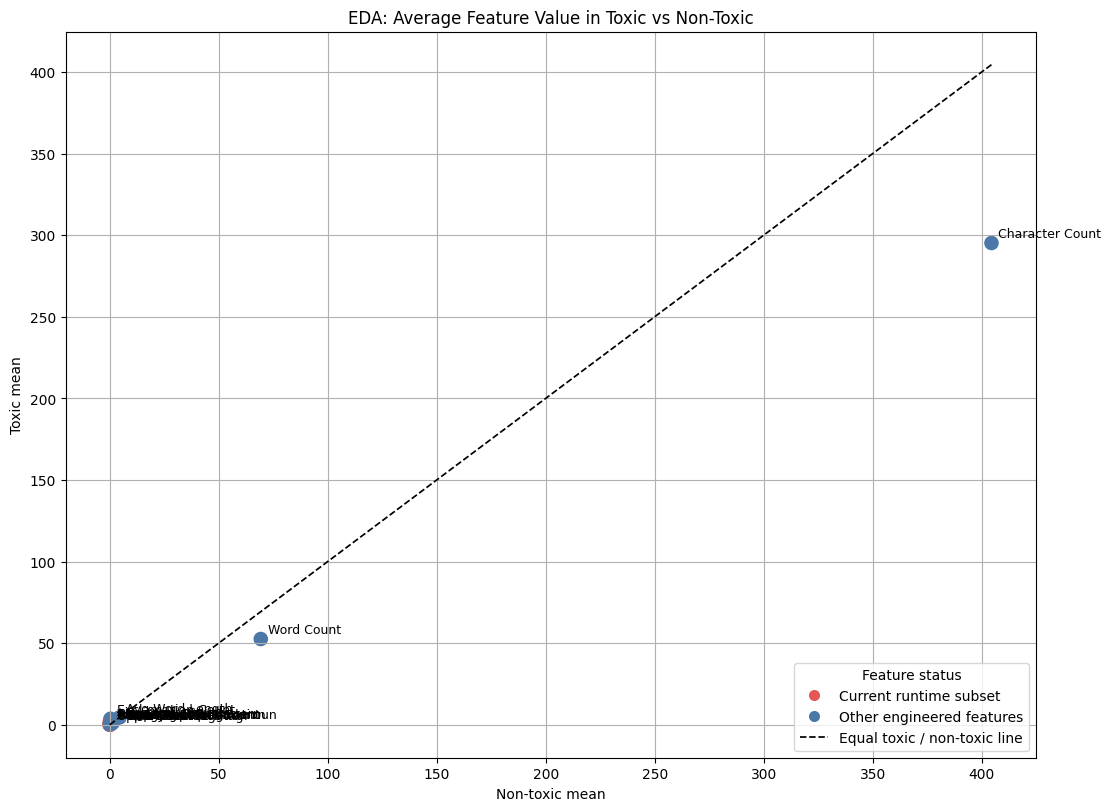

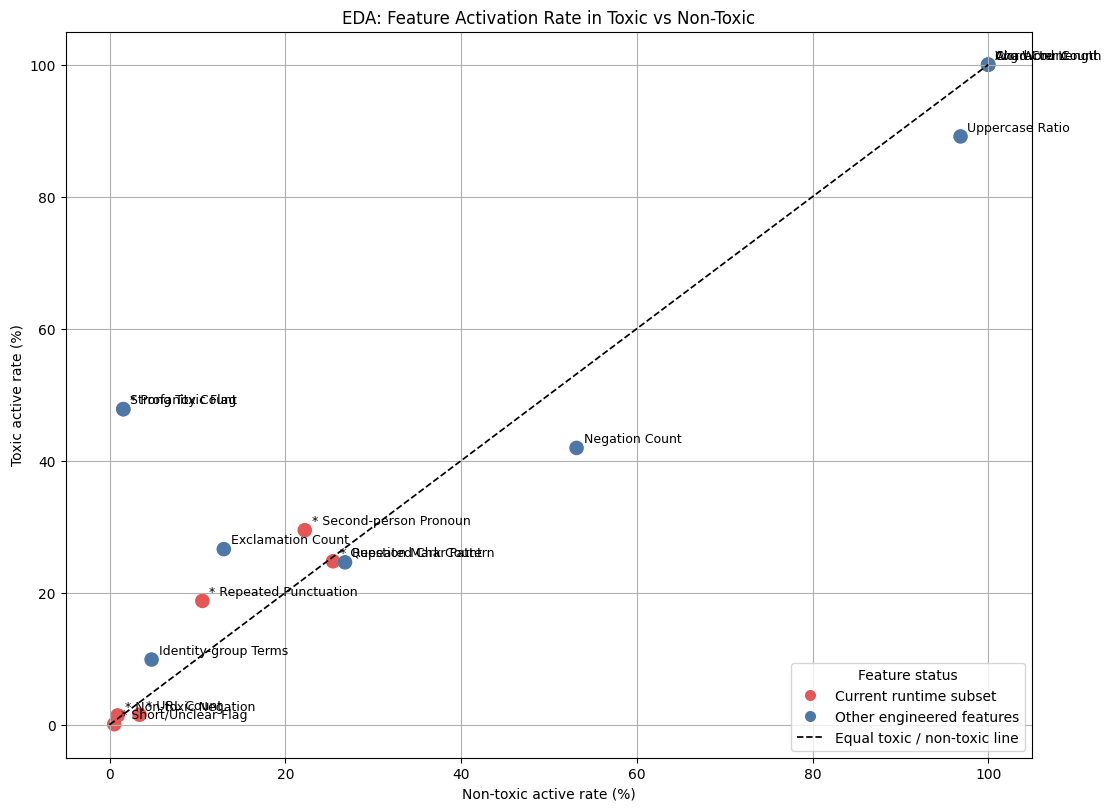

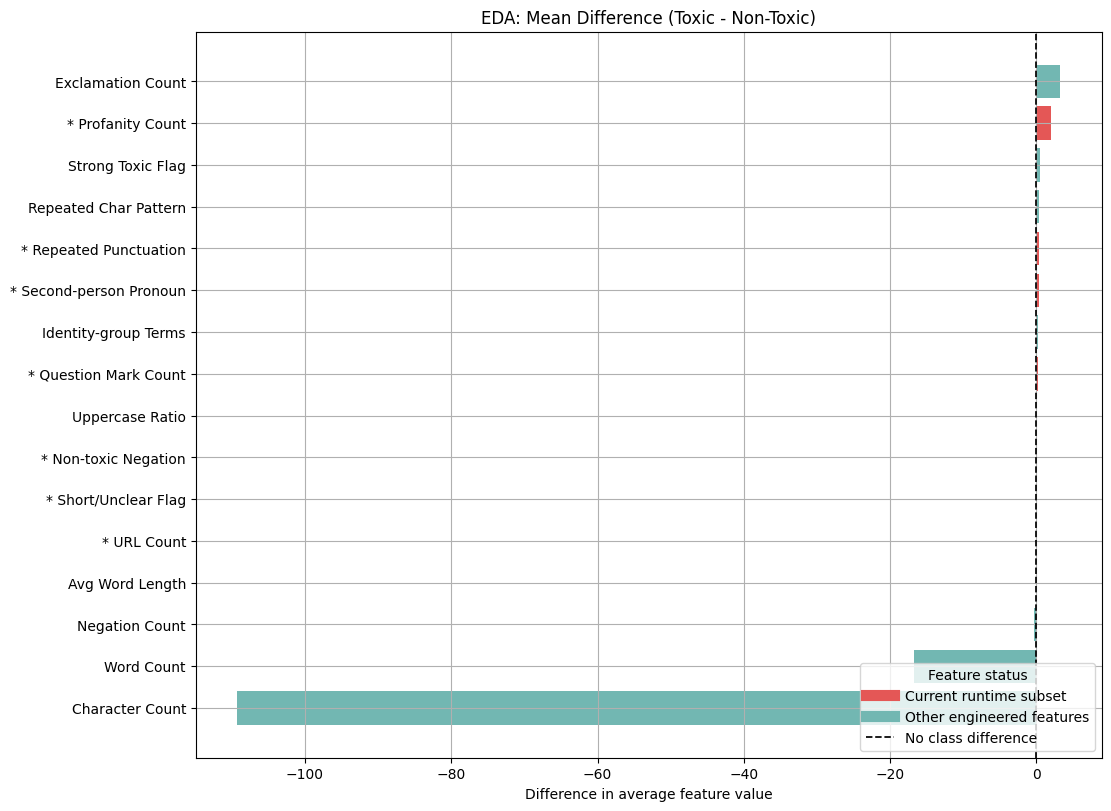

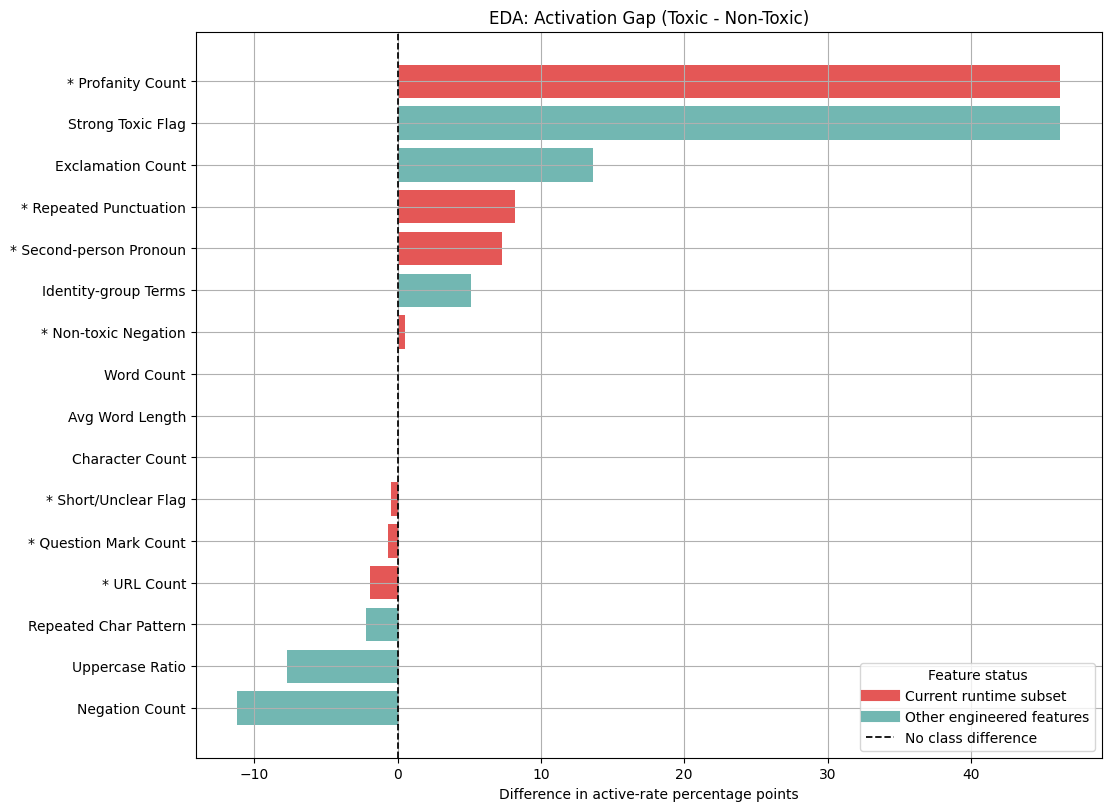

In [108]:
selected_features = set(FEATURE_COLUMNS)
feature_aliases = {
    "Short/Unclear Without Toxic Signal Flag": "Short/Unclear Flag",
    "Non-toxic Negation Pattern Count": "Non-toxic Negation",
    "Second-person Pronoun Count": "Second-person Pronoun",
    "Repeated Character Pattern Count": "Repeated Char Pattern",
    "Repeated Punctuation Count": "Repeated Punctuation",
    "Strong Toxic Signal Flag": "Strong Toxic Flag",
    "Identity-group Term Count": "Identity-group Terms",
    "Average Word Length": "Avg Word Length",
}
insight_rows = []

for feature in ALL_ENGINEERED_FEATURE_COLUMNS:
    toxic_series = analysis_df.loc[analysis_df["toxic"] == 1, feature]
    non_toxic_series = analysis_df.loc[analysis_df["toxic"] == 0, feature]
    toxic_active_rate = (toxic_series > 0).mean()
    non_toxic_active_rate = (non_toxic_series > 0).mean()
    non_toxic_mean = non_toxic_series.mean()
    toxic_mean = toxic_series.mean()

    insight_rows.append(
        {
            "feature": feature,
            "runtime_selected": feature in selected_features,
            "short_label": feature_aliases.get(feature, feature),
            "toxic_mean": toxic_mean,
            "non_toxic_mean": non_toxic_mean,
            "mean_gap": toxic_mean - non_toxic_mean,
            "mean_ratio": toxic_mean / max(non_toxic_mean, 1e-9),
            "toxic_active_rate": toxic_active_rate,
            "non_toxic_active_rate": non_toxic_active_rate,
            "activation_gap_pp": (toxic_active_rate - non_toxic_active_rate) * 100,
        }
    )

all_feature_insights = pd.DataFrame(insight_rows).sort_values(
    ["activation_gap_pp", "mean_gap"],
    ascending=[False, False],
).reset_index(drop=True)
all_feature_insights["plot_label"] = all_feature_insights.apply(
    lambda row: f"* {row['short_label']}" if row["runtime_selected"] else row["short_label"],
    axis=1,
)

display(
    all_feature_insights[
        [
            "feature",
            "runtime_selected",
            "toxic_mean",
            "non_toxic_mean",
            "mean_gap",
            "mean_ratio",
            "toxic_active_rate",
            "non_toxic_active_rate",
            "activation_gap_pp",
        ]
    ].round(3)
)

plot_df = all_feature_insights.copy()
selected_mask = plot_df["runtime_selected"]
point_colors = selected_mask.map({True: "#e45756", False: "#4c78a8"})

max_mean = max(plot_df["non_toxic_mean"].max(), plot_df["toxic_mean"].max())
fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
ax.scatter(plot_df["non_toxic_mean"], plot_df["toxic_mean"], s=90, c=point_colors)
ax.plot([0, max_mean], [0, max_mean], linestyle="--", color="black", linewidth=1.25)
for row in plot_df.itertuples(index=False):
    ax.annotate(row.plot_label, (row.non_toxic_mean, row.toxic_mean), xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_title("EDA: Average Feature Value in Toxic vs Non-Toxic")
ax.set_xlabel("Non-toxic mean")
ax.set_ylabel("Toxic mean")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#e45756", markersize=9, label="Current runtime subset"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#4c78a8", markersize=9, label="Other engineered features"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.25, label="Equal toxic / non-toxic line"),
    ],
    loc="lower right",
    title="Feature status",
)
plt.show()

max_rate = max(plot_df["non_toxic_active_rate"].max(), plot_df["toxic_active_rate"].max()) * 100
fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
ax.scatter(plot_df["non_toxic_active_rate"] * 100, plot_df["toxic_active_rate"] * 100, s=90, c=point_colors)
ax.plot([0, max_rate], [0, max_rate], linestyle="--", color="black", linewidth=1.25)
for row in plot_df.itertuples(index=False):
    ax.annotate(row.plot_label, (row.non_toxic_active_rate * 100, row.toxic_active_rate * 100), xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_title("EDA: Feature Activation Rate in Toxic vs Non-Toxic")
ax.set_xlabel("Non-toxic active rate (%)")
ax.set_ylabel("Toxic active rate (%)")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#e45756", markersize=9, label="Current runtime subset"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#4c78a8", markersize=9, label="Other engineered features"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.25, label="Equal toxic / non-toxic line"),
    ],
    loc="lower right",
    title="Feature status",
)
plt.show()

mean_gap_df = plot_df.sort_values("mean_gap", ascending=True)
gap_colors = mean_gap_df["runtime_selected"].map({True: "#e45756", False: "#72b7b2"})
fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
ax.barh(mean_gap_df["plot_label"], mean_gap_df["mean_gap"], color=gap_colors)
ax.axvline(0, linestyle="--", color="black", linewidth=1.25)
ax.set_title("EDA: Mean Difference (Toxic - Non-Toxic)")
ax.set_xlabel("Difference in average feature value")
ax.set_ylabel("")
ax.legend(
    handles=[
        Line2D([0], [0], color="#e45756", linewidth=8, label="Current runtime subset"),
        Line2D([0], [0], color="#72b7b2", linewidth=8, label="Other engineered features"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.25, label="No class difference"),
    ],
    loc="lower right",
    title="Feature status",
)
plt.show()

rate_gap_df = plot_df.sort_values("activation_gap_pp", ascending=True)
rate_colors = rate_gap_df["runtime_selected"].map({True: "#e45756", False: "#72b7b2"})
fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
ax.barh(rate_gap_df["plot_label"], rate_gap_df["activation_gap_pp"], color=rate_colors)
ax.axvline(0, linestyle="--", color="black", linewidth=1.25)
ax.set_title("EDA: Activation Gap (Toxic - Non-Toxic)")
ax.set_xlabel("Difference in active-rate percentage points")
ax.set_ylabel("")

ax.legend(
    handles=[
        Line2D([0], [0], color="#e45756", linewidth=8, label="Current runtime subset"),
        Line2D([0], [0], color="#72b7b2", linewidth=8, label="Other engineered features"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.25, label="No class difference"),
    ],
    loc="lower right",
    title="Feature status",
)
plt.show()


## Basic Feature Comparison

This chart compares the single-feature F1 gain over the text-only baseline for every feature we tested. The red bars mark the current runtime-selected feature subset, while Word Count and Average Word Length are highlighted to show that they were tested as basic features but are not part of the active runtime set.


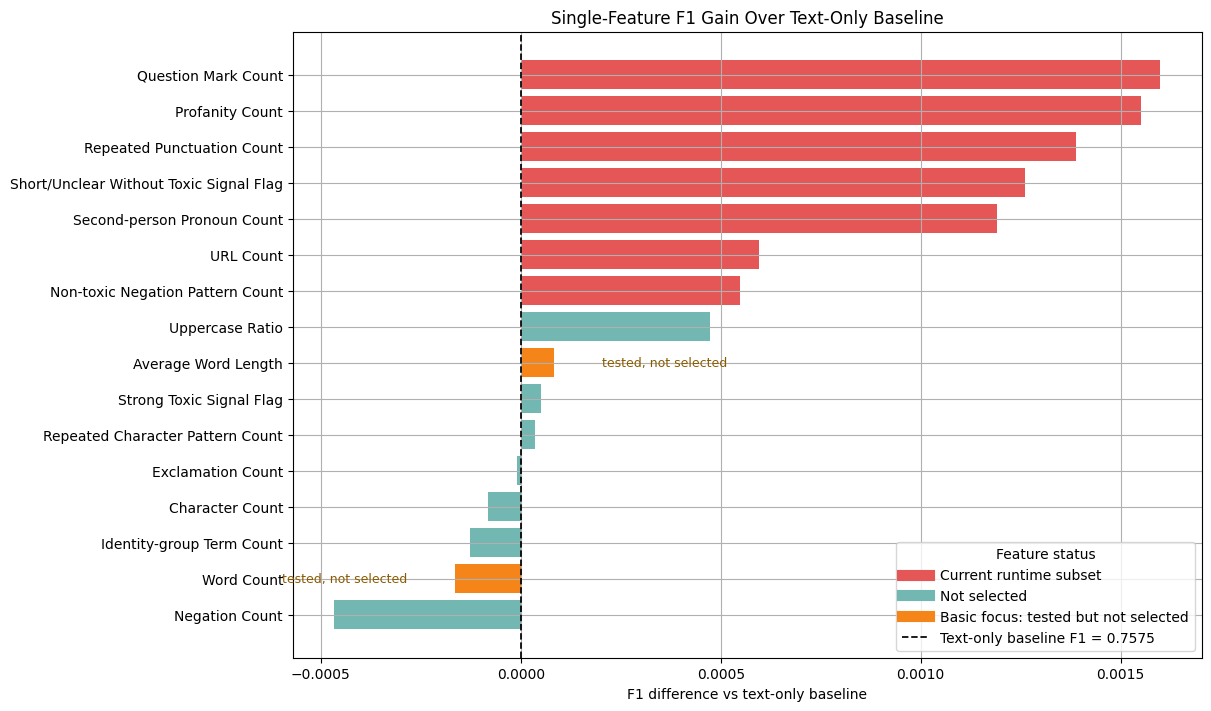

In [109]:
metadata_path = Path("optuna_feature_test_metadata.pkl")
if not metadata_path.exists():
    metadata_path = Path("src/optuna_feature_test_metadata.pkl")

experiment_meta = pickle.loads(metadata_path.read_bytes())
single_feature_effects = pd.DataFrame(experiment_meta["single_feature_effects"]).copy()
baseline_f1 = next(item["f1"] for item in experiment_meta["summary"] if item["name"] == "Text only")
selected_features = set(FEATURE_COLUMNS)
basic_focus = {"Word Count", "Average Word Length"}

single_feature_effects["selected"] = single_feature_effects["feature"].isin(selected_features)
single_feature_effects["basic_focus"] = single_feature_effects["feature"].isin(basic_focus)
single_feature_effects = single_feature_effects.sort_values("delta_vs_text_only", ascending=False).reset_index(drop=True)

bar_colors = single_feature_effects.apply(
    lambda row: "#f58518" if row["basic_focus"] else ("#e45756" if row["selected"] else "#72b7b2"),
    axis=1,
)

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
y_pos = np.arange(len(single_feature_effects))
ax.barh(y_pos, single_feature_effects["delta_vs_text_only"], color=bar_colors)
ax.axvline(0, color="black", linestyle="--", linewidth=1.25)
ax.set_yticks(y_pos)
ax.set_yticklabels(single_feature_effects["feature"])
ax.invert_yaxis()
ax.set_title("Single-Feature F1 Gain Over Text-Only Baseline")
ax.set_xlabel("F1 difference vs text-only baseline")
ax.set_ylabel("")

for y, row in enumerate(single_feature_effects.itertuples(index=False)):
    if row.basic_focus:
        delta = row.delta_vs_text_only
        offset = 0.00012 if delta >= 0 else -0.00012
        ax.text(
            delta + offset,
            y,
            "tested, not selected",
            va="center",
            ha="left" if delta >= 0 else "right",
            fontsize=9,
            color="#8a5a00",
        )

legend_handles = [
    Line2D([0], [0], color="#e45756", linewidth=8, label="Current runtime subset"),
    Line2D([0], [0], color="#72b7b2", linewidth=8, label="Not selected"),
    Line2D([0], [0], color="#f58518", linewidth=8, label="Basic focus: tested but not selected"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.25, label=f"Text-only baseline F1 = {baseline_f1:.4f}"),
]
ax.legend(handles=legend_handles, title="Feature status", loc="lower right")

plt.show()


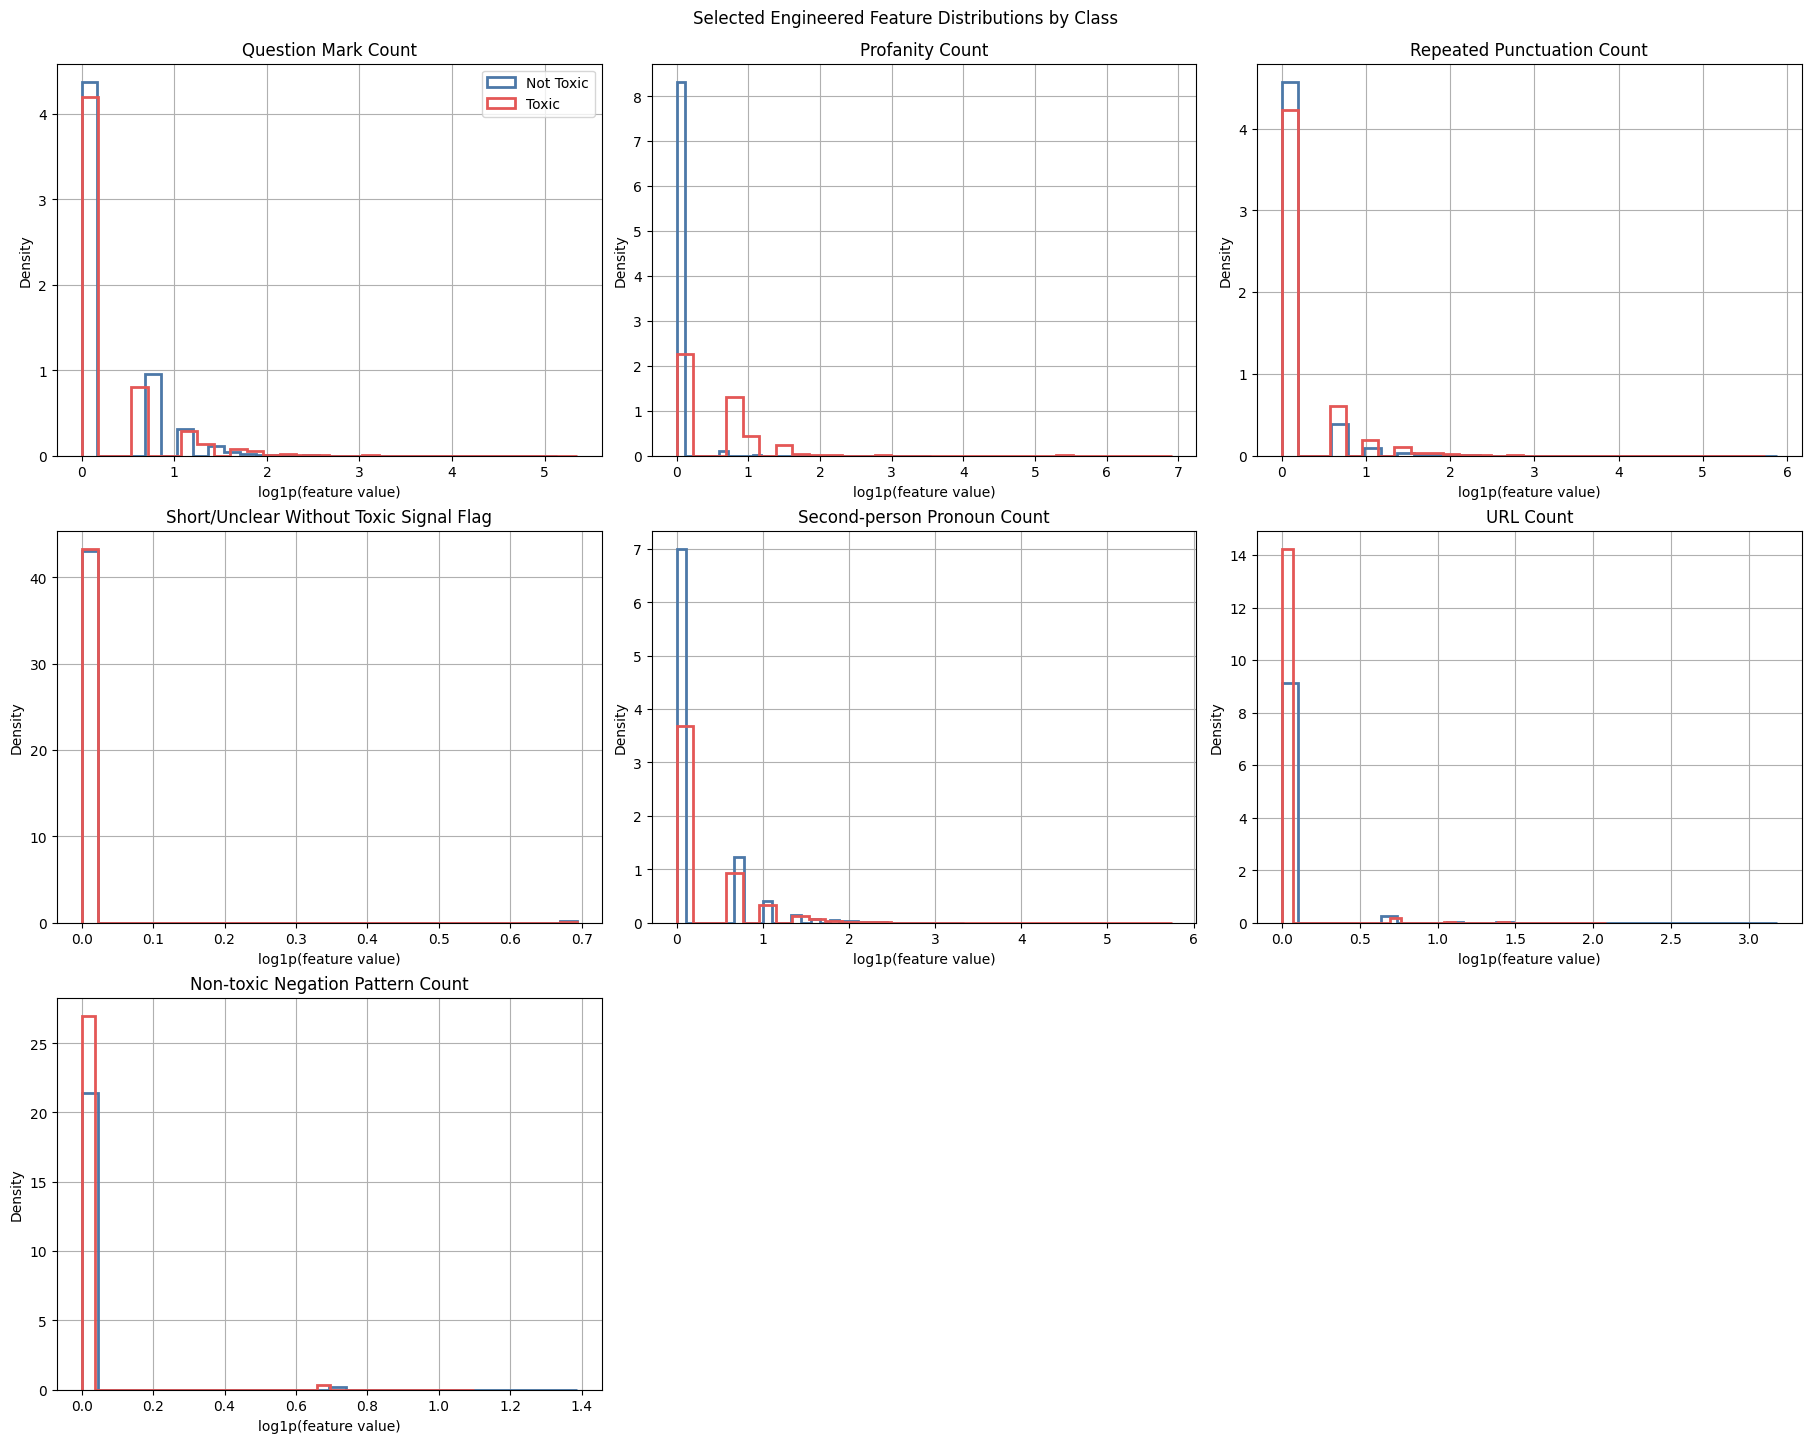

In [110]:
feature_plot_sample = analysis_df.sample(n=min(50000, len(analysis_df)), random_state=42).copy()

fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
axes = axes.ravel()

for ax, feature in zip(axes, FEATURE_COLUMNS):
    not_toxic = feature_plot_sample.loc[feature_plot_sample["label"] == "Not Toxic", feature].clip(lower=0)
    toxic = feature_plot_sample.loc[feature_plot_sample["label"] == "Toxic", feature].clip(lower=0)

    ax.hist(
        np.log1p(not_toxic),
        bins=30,
        density=True,
        histtype="step",
        linewidth=2,
        color=PALETTE["Not Toxic"],
        label="Not Toxic",
    )
    ax.hist(
        np.log1p(toxic),
        bins=30,
        density=True,
        histtype="step",
        linewidth=2,
        color=PALETTE["Toxic"],
        label="Toxic",
    )
    ax.set_title(feature)
    ax.set_xlabel("log1p(feature value)")
    ax.set_ylabel("Density")

for ax in axes[len(FEATURE_COLUMNS):]:
    ax.axis("off")

axes[0].legend()
fig.suptitle("Selected Engineered Feature Distributions by Class", y=1.02)
plt.show()


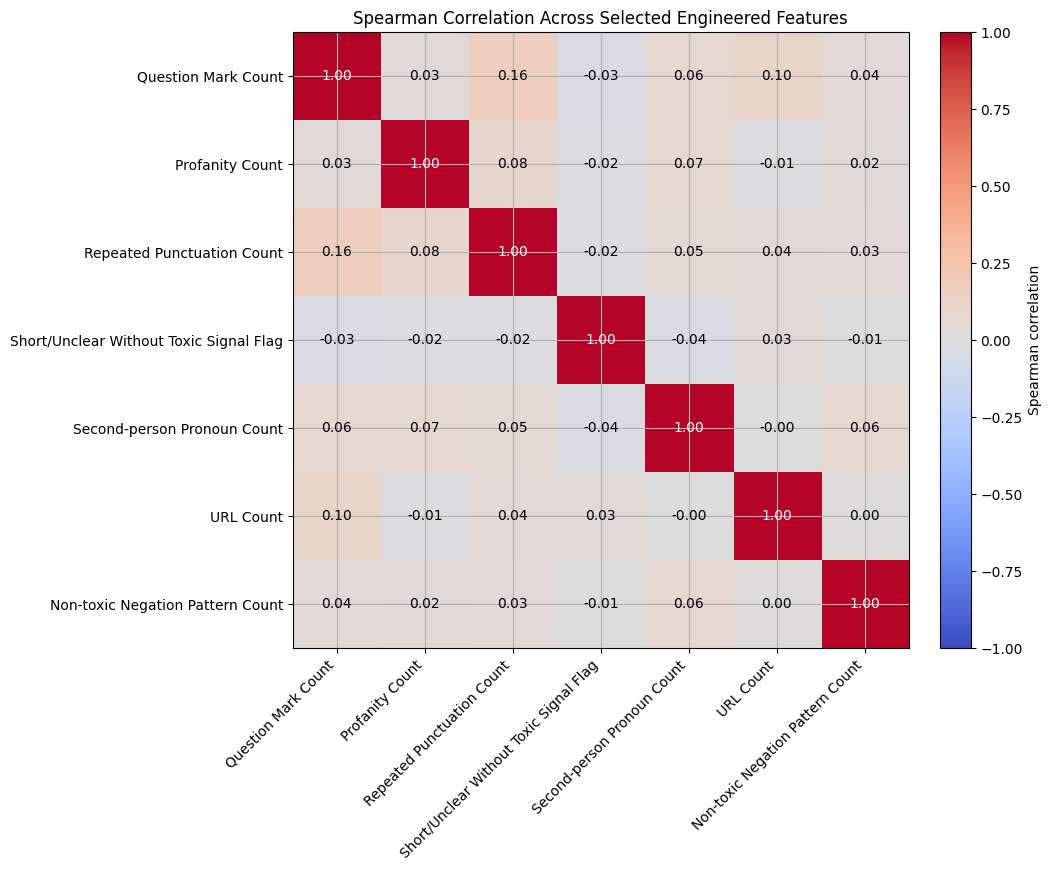

In [111]:
correlation = analysis_df[FEATURE_COLUMNS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLUMNS)))
ax.set_xticklabels(FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURE_COLUMNS)))
ax.set_yticklabels(FEATURE_COLUMNS)

for row in range(len(FEATURE_COLUMNS)):
    for col in range(len(FEATURE_COLUMNS)):
        value = correlation.iloc[row, col]
        text_color = "white" if abs(value) >= 0.5 else "black"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
ax.set_title("Spearman Correlation Across Selected Engineered Features")
plt.show()


## Saved Model Comparison and Winner

This section compares the saved artifact families on the shared word-only pipeline and the same 20% stratified split used throughout the tuning notebooks.

The project’s main tuning target is F1, so the winner below is selected by held-out test F1. The confusion matrix that follows is computed for that winner.


,name,feature_count,F1,Precision,Recall,ROC-AUC
0,Optuna Feature Test,7,0.8167,0.8128,0.8205,0.9824
1,Runtime Best Model,7,0.8123,0.8126,0.8120,0.9812
2,Optuna Main,16,0.8036,0.7843,0.8238,0.9788
3,Grid Search,16,0.7973,0.7962,0.7983,0.9738
4,Random Search,16,0.7879,0.7866,0.7891,0.9718


Winner by held-out F1: Optuna Feature Test


,Winner,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Optuna Feature Test,0.9647,0.8128,0.8205,0.8167,28278,578,549,2510


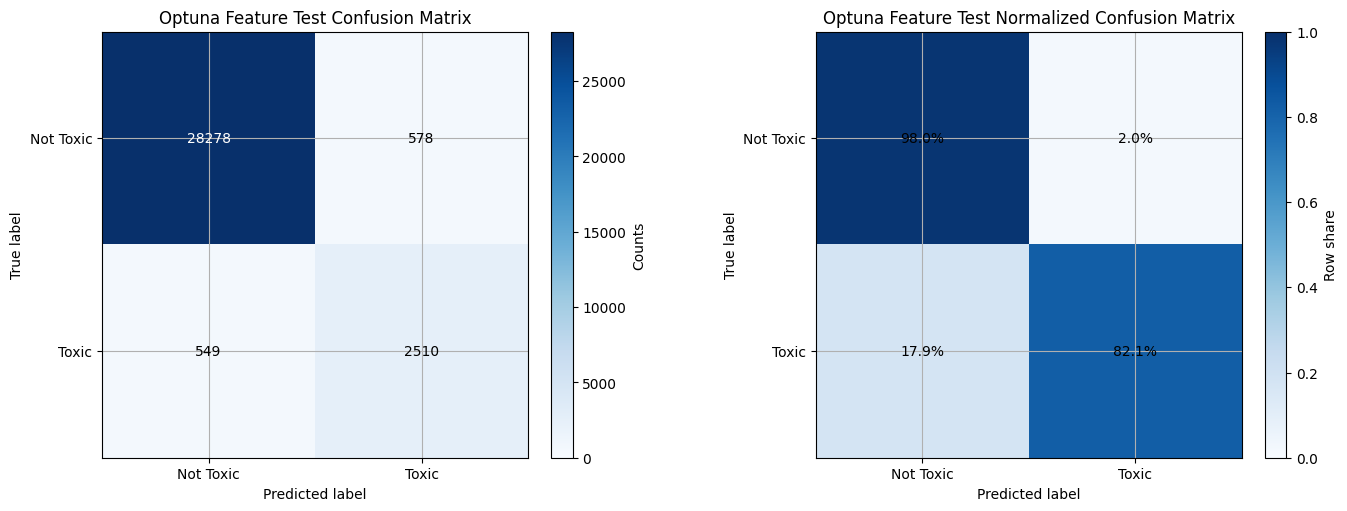

In [112]:
src_dir = Path('.')
if not (src_dir / 'grid_search_best_model.pkl').exists():
    src_dir = Path('src')

def load_saved_pickle(filename: str):
    return pickle.loads((src_dir / filename).read_bytes())

def normalize_scaler(scaler, feature_columns):
    expected = getattr(scaler, 'n_features_in_', len(feature_columns))
    if expected == len(feature_columns):
        return scaler
    if expected == len(ALL_ENGINEERED_FEATURE_COLUMNS):
        return _reduce_scaler_to_features(
            scaler,
            ALL_ENGINEERED_FEATURE_COLUMNS,
            list(feature_columns),
        )
    raise ValueError(f'Scaler expects {expected} features but got {len(feature_columns)}.')

def evaluate_saved_artifact(name, model_file, word_file, scaler_file, feature_columns):
    feature_columns = list(feature_columns)
    split_df = analysis_df[["clean_text", "toxic", *feature_columns]].copy()
    _, test_df = train_test_split(
        split_df,
        test_size=0.20,
        random_state=42,
        stratify=split_df["toxic"],
    )

    word_vec = load_saved_pickle(word_file)
    scaler = normalize_scaler(load_saved_pickle(scaler_file), feature_columns)
    model = load_saved_pickle(model_file)

    x_word = word_vec.transform(test_df["clean_text"])
    x_eng = csr_matrix(scaler.transform(test_df[feature_columns].values))
    x_test = hstack([x_word, x_eng], format="csr")

    y_true = test_df["toxic"].to_numpy()
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    return {
        "name": name,
        "feature_count": len(feature_columns),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "y_true": y_true,
        "y_pred": y_pred,
    }

optuna_feature_meta = load_saved_pickle('optuna_feature_test_metadata.pkl')
runtime_meta = load_saved_pickle('best_model_metadata.pkl')

artifact_specs = [
    {
        "name": "Random Search",
        "model_file": "random_search_best_model.pkl",
        "word_file": "random_search_word_vectorizer.pkl",
        "scaler_file": "random_search_scaler.pkl",
        "feature_columns": ALL_ENGINEERED_FEATURE_COLUMNS,
    },
    {
        "name": "Grid Search",
        "model_file": "grid_search_best_model.pkl",
        "word_file": "grid_search_word_vectorizer.pkl",
        "scaler_file": "grid_search_scaler.pkl",
        "feature_columns": ALL_ENGINEERED_FEATURE_COLUMNS,
    },
    {
        "name": "Optuna Main",
        "model_file": "optuna_best_model.pkl",
        "word_file": "optuna_word_vectorizer.pkl",
        "scaler_file": "optuna_scaler.pkl",
        "feature_columns": ALL_ENGINEERED_FEATURE_COLUMNS,
    },
    {
        "name": "Optuna Feature Test",
        "model_file": "optuna_feature_test_best_model.pkl",
        "word_file": "optuna_feature_test_word_vectorizer.pkl",
        "scaler_file": "optuna_feature_test_scaler.pkl",
        "feature_columns": optuna_feature_meta["feature_columns"],
    },
    {
        "name": "Runtime Best Model",
        "model_file": "best_model_final.pkl",
        "word_file": "best_model_word_vectorizer.pkl",
        "scaler_file": "best_model_scaler.pkl",
        "feature_columns": runtime_meta["feature_columns"],
    },
]

comparison_rows = [evaluate_saved_artifact(**spec) for spec in artifact_specs]
comparison_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in {"y_true", "y_pred"}} for row in comparison_rows]
).sort_values(["F1", "ROC-AUC"], ascending=False).reset_index(drop=True)

display(comparison_df.round(4))

winner_row = comparison_rows[int(comparison_df.index[0])]
winner_name = comparison_df.iloc[0]["name"]
print(f"Winner by held-out F1: {winner_name}")

winner_full = next(row for row in comparison_rows if row["name"] == winner_name)
cm = confusion_matrix(winner_full["y_true"], winner_full["y_pred"])
tn, fp, fn, tp = cm.ravel()
cm_norm = cm / cm.sum(axis=1, keepdims=True)

metrics_df = pd.DataFrame(
    [
        {
            "Winner": winner_name,
            "Accuracy": (tn + tp) / cm.sum(),
            "Precision": precision_score(winner_full["y_true"], winner_full["y_pred"]),
            "Recall": recall_score(winner_full["y_true"], winner_full["y_pred"]),
            "F1": f1_score(winner_full["y_true"], winner_full["y_pred"]),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
        }
    ]
)
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plots = [
    (cm, f"{winner_name} Confusion Matrix", "Counts", False),
    (cm_norm, f"{winner_name} Normalized Confusion Matrix", "Row share", True),
]

for ax, (matrix, title, label_text, normalized) in zip(axes, plots):
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1 if normalized else cm.max())
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not Toxic", "Toxic"])
    ax.set_yticklabels(["Not Toxic", "Toxic"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    for row in range(2):
        for col in range(2):
            value = matrix[row, col]
            text_value = f"{value:.0f}" if not normalized else f"{value:.1%}"
            text_color = "white" if (not normalized and value > cm.max() / 2) else "black"
            ax.text(col, row, text_value, ha="center", va="center", color=text_color)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label=label_text)

plt.show()


## Suggested Talking Points

- Cleaning reduces punctuation, casing noise, URLs, and formatting variance before feature extraction.
- The raw-versus-clean plots show that the model is not learning directly from messy surface form alone; it learns from normalized patterns.
- The example bridge table makes it easy to explain how specific comments activate specific engineered features.
- The scorecard and feature plots help justify why some engineered features were kept and others were weaker or more redundant.
- In the current saved-artifact comparison, `Grid Search` gives the best held-out F1, while `Optuna Feature Test` remains the strongest compact `7`-feature option and has the best ROC-AUC.
